<a href="https://colab.research.google.com/github/Khyati-01-sahu/sales-forecasting/blob/main/Sales_forecasting_%26_Trend_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  SALES FORECASTING  |  ARIMA  |  Jul-Dec '25
✅  Synthetic dataset created  (54 months, Jan-2021 → Jun-2025)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   STEP 1 │ DATA CLEANING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw shape          : (54, 2)
  Duplicate rows     : 0 removed
  Missing values     : 0 filled (ffill/bfill)
  Outliers capped    : 0
  Clean shape        : (54, 1)
  Date range         : 2021-01-01 → 2025-06-01
  Sales – min / max  : ₹25,698 / ₹130,818

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   STEP 2 │ FEATURE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ADF p-value        : 0.8950  →  Non-stationary (differencing needed)
  Peak demand months : ['Apr', 'Mar', 'May']
  YoY growth (last)  : -42.1%
  Trend direction    : ↑ Upward

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   STEP 3 │ ARIMA MODELLING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train size         : 43 months
  Test  size         : 11  months

  Auto-selecting ARIMA(p,d,q) via AIC grid search …
  Best order         : ARIMA(0, 1, 0)  │  AIC = 880.40

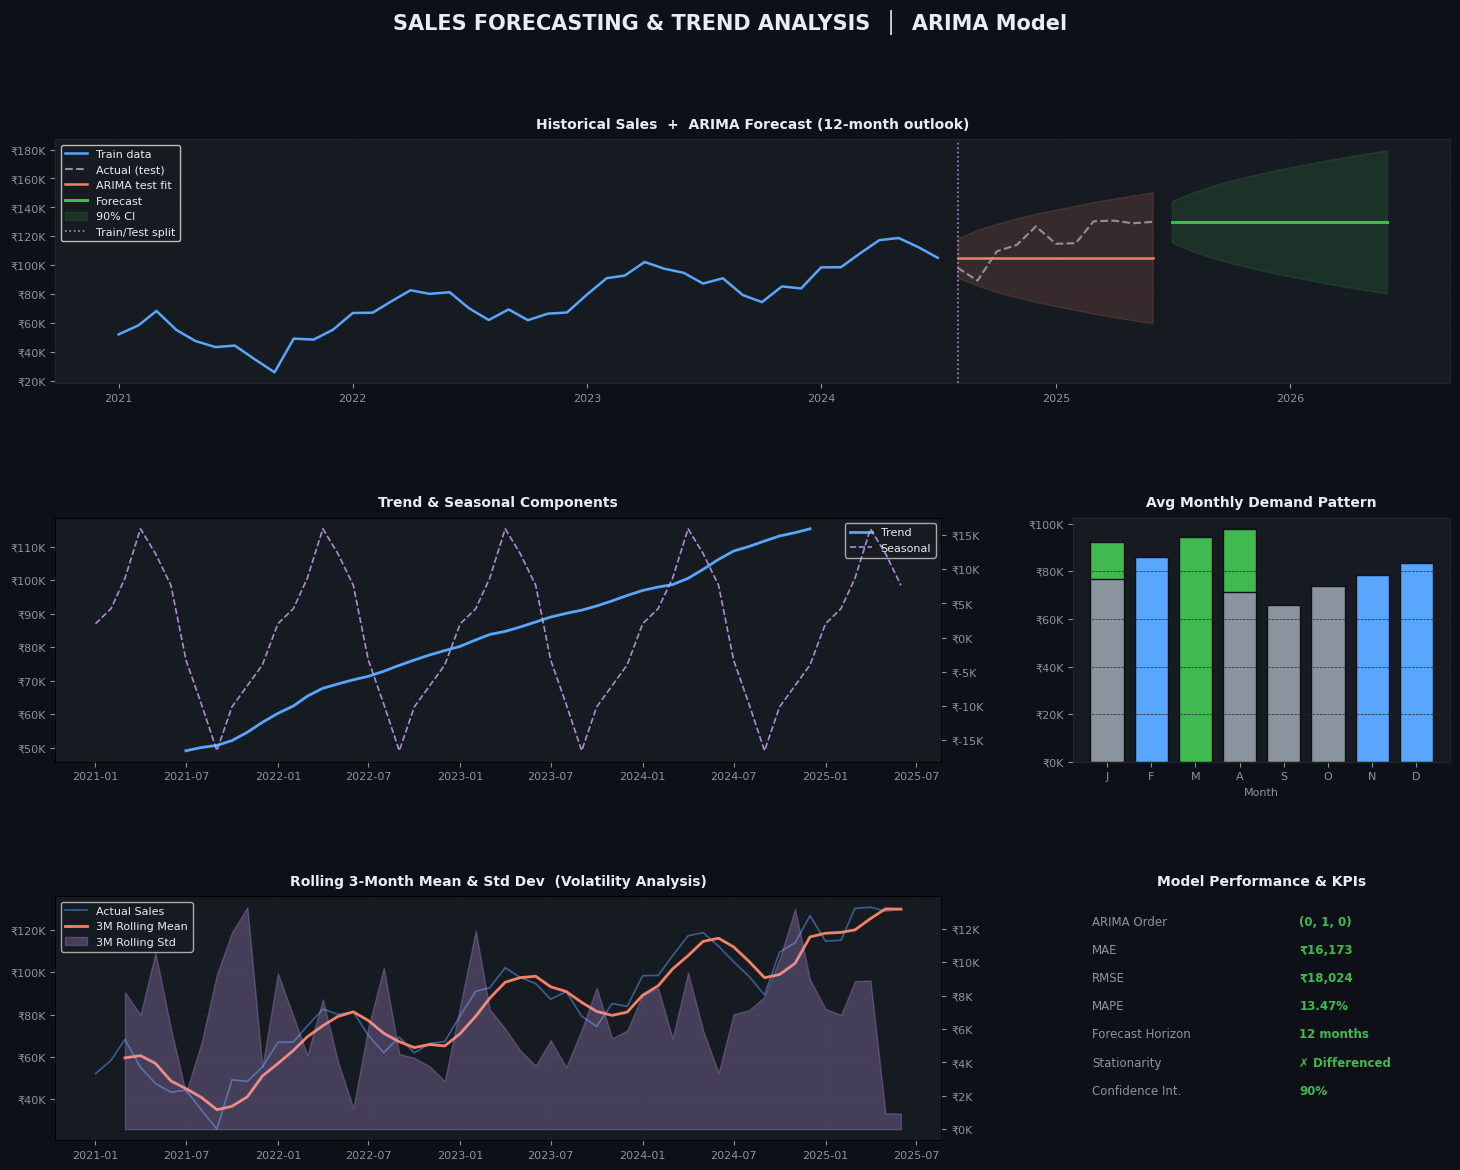


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   STEP 5 │ BUSINESS INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📈  TREND     – Sales show a clear upward trend. Forecast avg: ₹129,947/mo (+54.8% vs historical mean).
  📅  SEASONALITY – Demand peaks in Apr, Mar, May. These are prime stocking periods.
  📉  SLOW MONTHS – Sep, Aug, Oct show lower demand → opportunity to push promotions or clear inventory.
  🎯  ACCURACY  – ARIMA achieved MAPE of 13.47%, indicating moderate forecast reliability.
  📦  INVENTORY – Stock up 15–20% above forecast in peak months to buffer against demand spikes.
  💡  PLANNING  – Use 90% CI bands for conservative (lower bound) vs optimistic (upper bound) procurement scenarios.

✅  All done! Output saved to sales_forecast_dashboard.png


In [4]:


# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product

# ─────────────────────────────────────────────
# 2. DATA LOADING
#    ► Replace the path below with your actual file
#      e.g. df = pd.read_csv("sales_data.csv")
# ─────────────────────────────────────────────
def load_data(filepath: str = None) -> pd.DataFrame:
    """
    Load sales data from CSV or generate synthetic data for demonstration.
    Expected CSV columns: 'Date', 'Sales'  (or 'date', 'sales')
    """
    if filepath:
        df = pd.read_csv(filepath, parse_dates=["Date"])
        df.columns = df.columns.str.strip().str.title()
        return df

    # ── Synthetic dataset (realistic monthly sales 2021-2025) ─────────────
    np.random.seed(42)
    dates = pd.date_range(start="2021-01-01", end="2025-06-01", freq="MS")
    n     = len(dates)

    trend      = np.linspace(50_000, 120_000, n)                     # upward trend
    seasonality = 15_000 * np.sin(2 * np.pi * np.arange(n) / 12)    # annual cycle
    noise       = np.random.normal(0, 4_000, n)

    # add a COVID dip and a post-festival spike for realism
    dip   = np.zeros(n); dip[3:9]   = -20_000    # Apr–Sep 2021 slowdown
    spike = np.zeros(n); spike[45:48] = 18_000   # Oct–Dec 2024 festive surge

    sales = trend + seasonality + noise + dip + spike
    sales = np.clip(sales, 0, None)

    df = pd.DataFrame({"Date": dates, "Sales": sales.round(2)})
    print("✅  Synthetic dataset created  (54 months, Jan-2021 → Jun-2025)")
    return df

# ─────────────────────────────────────────────
# 3. DATA CLEANING
# ─────────────────────────────────────────────
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Handles missing values, duplicates, type coercion, and outlier capping.
    """
    print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("   STEP 1 │ DATA CLEANING")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    original_shape = df.shape
    print(f"  Raw shape          : {original_shape}")

    # ── Column normalisation
    df.columns = df.columns.str.strip().str.title()
    if "Date"  not in df.columns: raise KeyError("Column 'Date' not found.")
    if "Sales" not in df.columns: raise KeyError("Column 'Sales' not found.")

    # ── Parse & sort dates
    df["Date"]  = pd.to_datetime(df["Date"])
    df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    # ── Remove duplicates
    dupes = df.duplicated(subset="Date").sum()
    df = df.drop_duplicates(subset="Date")
    print(f"  Duplicate rows     : {dupes} removed")

    # ── Missing values – forward fill then backward fill
    missing = df["Sales"].isna().sum()
    df["Sales"] = df["Sales"].fillna(method="ffill").fillna(method="bfill")
    print(f"  Missing values     : {missing} filled (ffill/bfill)")

    # ── Outlier capping (IQR method)
    Q1, Q3 = df["Sales"].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((df["Sales"] < lower) | (df["Sales"] > upper)).sum()
    df["Sales"] = df["Sales"].clip(lower, upper)
    print(f"  Outliers capped    : {outliers}")

    # ── Set Date as index
    df = df.set_index("Date").asfreq("MS")

    print(f"  Clean shape        : {df.shape}")
    print(f"  Date range         : {df.index[0].date()} → {df.index[-1].date()}")
    print(f"  Sales – min / max  : ₹{df['Sales'].min():,.0f} / ₹{df['Sales'].max():,.0f}")
    return df

# ─────────────────────────────────────────────
# 4. FEATURE ANALYSIS
#    Trend • Seasonality • Demand Patterns
# ─────────────────────────────────────────────
def feature_analysis(df: pd.DataFrame) -> dict:
    """
    Computes rolling statistics, seasonal decomposition, and ADF stationarity test.
    Returns a dict of analysis results.
    """
    print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("   STEP 2 │ FEATURE ANALYSIS")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    series = df["Sales"]

    # ── Rolling statistics
    roll_mean = series.rolling(3).mean()
    roll_std  = series.rolling(3).std()

    # ── Seasonal decomposition (additive)
    decomp = seasonal_decompose(series, model="additive", period=12)

    # ── ADF Stationarity Test
    adf_result  = adfuller(series.dropna())
    is_stationary = adf_result[1] < 0.05
    print(f"  ADF p-value        : {adf_result[1]:.4f}  →  {'Stationary ✓' if is_stationary else 'Non-stationary (differencing needed)'}")

    # ── Peak demand months
    monthly_avg = series.groupby(series.index.month).mean()
    peak_months = monthly_avg.nlargest(3).index.tolist()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    print(f"  Peak demand months : {[month_names[m-1] for m in peak_months]}")

    # ── Year-on-year growth
    yearly = series.resample("YE").sum()
    if len(yearly) >= 2:
        yoy = ((yearly.iloc[-1] - yearly.iloc[-2]) / yearly.iloc[-2]) * 100
        print(f"  YoY growth (last)  : {yoy:+.1f}%")

    print(f"  Trend direction    : {'↑ Upward' if decomp.trend.dropna().iloc[-1] > decomp.trend.dropna().iloc[0] else '↓ Downward'}")

    return {
        "series"      : series,
        "roll_mean"   : roll_mean,
        "roll_std"    : roll_std,
        "decomp"      : decomp,
        "stationarity": is_stationary,
        "monthly_avg" : monthly_avg,
    }

# ─────────────────────────────────────────────
# 5. ARIMA MODEL
# ─────────────────────────────────────────────
def auto_select_arima_order(series: pd.Series) -> tuple:
    """
    Grid-search over (p,d,q) space and return the order with lowest AIC.
    Search space is kept small for speed; expand for deeper tuning.
    """
    print("\n  Auto-selecting ARIMA(p,d,q) via AIC grid search …")
    best_aic, best_order = np.inf, (1, 1, 1)

    for p, d, q in product(range(3), range(2), range(3)):
        try:
            aic = ARIMA(series, order=(p, d, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, d, q)
        except Exception:
            continue

    print(f"  Best order         : ARIMA{best_order}  │  AIC = {best_aic:.2f}")
    return best_order


def build_arima_model(series: pd.Series, forecast_steps: int = 12):
    """
    Trains ARIMA, generates in-sample fit + out-of-sample forecast,
    computes evaluation metrics, and returns all artefacts.
    """
    print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("   STEP 3 │ ARIMA MODELLING")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    # ── Train / test split (80/20)
    split = int(len(series) * 0.80)
    train, test = series.iloc[:split], series.iloc[split:]
    print(f"  Train size         : {len(train)} months")
    print(f"  Test  size         : {len(test)}  months")

    order = auto_select_arima_order(train)

    # ── Fit on training data
    model  = ARIMA(train, order=order)
    result = model.fit()

    # ── In-sample predictions on test set
    pred_obj   = result.get_forecast(steps=len(test))
    pred_mean  = pred_obj.predicted_mean
    pred_ci    = pred_obj.conf_int(alpha=0.10)   # 90% CI

    # ── Evaluation metrics
    mae  = mean_absolute_error(test, pred_mean)
    rmse = np.sqrt(mean_squared_error(test, pred_mean))
    mape = (np.abs((test.values - pred_mean.values) / test.values) * 100).mean()
    print(f"\n  ── Evaluation on Test Set ──")
    print(f"  MAE                : ₹{mae:,.0f}")
    print(f"  RMSE               : ₹{rmse:,.0f}")
    print(f"  MAPE               : {mape:.2f}%")

    # ── Re-fit on full data for future forecast
    final_model  = ARIMA(series, order=order).fit()
    future_obj   = final_model.get_forecast(steps=forecast_steps)
    future_mean  = future_obj.predicted_mean
    future_ci    = future_obj.conf_int(alpha=0.10)

    # ── Future date index
    last_date    = series.index[-1]
    future_index = pd.date_range(start=last_date + pd.DateOffset(months=1),
                                 periods=forecast_steps, freq="MS")
    future_mean.index = future_index
    future_ci.index   = future_index

    print(f"\n  ── Future Forecast ({forecast_steps} months) ──")
    forecast_df = pd.DataFrame({
        "Forecast"  : future_mean.round(0),
        "Lower_90"  : future_ci.iloc[:, 0].round(0),
        "Upper_90"  : future_ci.iloc[:, 1].round(0),
    })
    print(forecast_df.to_string())

    return {
        "order"       : order,
        "result"      : result,
        "train"       : train,
        "test"        : test,
        "pred_mean"   : pred_mean,
        "pred_ci"     : pred_ci,
        "future_mean" : future_mean,
        "future_ci"   : future_ci,
        "forecast_df" : forecast_df,
        "mae" : mae, "rmse": rmse, "mape": mape,
    }

# ─────────────────────────────────────────────
# 6. VISUALISATION  (5-panel dashboard)
# ─────────────────────────────────────────────
PALETTE = {
    "bg"      : "#0d1117",
    "panel"   : "#161b22",
    "accent1" : "#58a6ff",   # blue  – historical
    "accent2" : "#3fb950",   # green – forecast
    "accent3" : "#f78166",   # red   – test pred
    "accent4" : "#d2a8ff",   # purple
    "text"    : "#e6edf3",
    "muted"   : "#8b949e",
    "grid"    : "#21262d",
}

def _style_ax(ax, title: str = ""):
    ax.set_facecolor(PALETTE["panel"])
    ax.tick_params(colors=PALETTE["muted"], labelsize=8)
    ax.xaxis.label.set_color(PALETTE["muted"])
    ax.yaxis.label.set_color(PALETTE["muted"])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["grid"])
    ax.grid(color=PALETTE["grid"], linestyle="--", linewidth=0.5, alpha=0.7)
    if title:
        ax.set_title(title, color=PALETTE["text"], fontsize=10,
                     fontweight="bold", pad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"₹{x/1000:.0f}K"))


def plot_dashboard(analysis: dict, arima: dict):
    print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("   STEP 4 │ VISUALISATION")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    fig = plt.figure(figsize=(18, 13), facecolor=PALETTE["bg"])
    fig.suptitle(
        "SALES FORECASTING & TREND ANALYSIS  │  ARIMA Model",
        color=PALETTE["text"], fontsize=15, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)
    ax1 = fig.add_subplot(gs[0, :])        # row 0 – full width
    ax2 = fig.add_subplot(gs[1, :2])       # row 1 – left 2/3
    ax3 = fig.add_subplot(gs[1, 2])        # row 1 – right 1/3
    ax4 = fig.add_subplot(gs[2, :2])       # row 2 – left 2/3
    ax5 = fig.add_subplot(gs[2, 2])        # row 2 – right 1/3

    series = analysis["series"]
    train  = arima["train"]
    test   = arima["test"]

    # ─── Panel 1 : Historical + Forecast ──────────────────────────────────
    _style_ax(ax1, "Historical Sales  +  ARIMA Forecast (12-month outlook)")

    ax1.plot(train.index, train, color=PALETTE["accent1"], lw=1.8,
             label="Train data", zorder=3)
    ax1.plot(test.index, test, color=PALETTE["muted"], lw=1.5,
             linestyle="--", label="Actual (test)", zorder=3)
    ax1.plot(arima["pred_mean"].index, arima["pred_mean"],
             color=PALETTE["accent3"], lw=1.8, label="ARIMA test fit", zorder=4)
    ax1.fill_between(arima["pred_ci"].index,
                     arima["pred_ci"].iloc[:, 0],
                     arima["pred_ci"].iloc[:, 1],
                     color=PALETTE["accent3"], alpha=0.15)

    ax1.plot(arima["future_mean"].index, arima["future_mean"],
             color=PALETTE["accent2"], lw=2.2, label="Forecast", zorder=5)
    ax1.fill_between(arima["future_ci"].index,
                     arima["future_ci"].iloc[:, 0],
                     arima["future_ci"].iloc[:, 1],
                     color=PALETTE["accent2"], alpha=0.15, label="90% CI")
    ax1.axvline(test.index[0], color=PALETTE["accent4"],
                lw=1.2, linestyle=":", alpha=0.8, label="Train/Test split")
    ax1.legend(fontsize=8, facecolor=PALETTE["panel"],
               labelcolor=PALETTE["text"], framealpha=0.9)

    # ─── Panel 2 : Seasonal Decomposition (Trend + Seasonal) ─────────────
    _style_ax(ax2, "Trend & Seasonal Components")
    decomp = analysis["decomp"]
    ax2b   = ax2.twinx()
    ax2.plot(decomp.trend.index, decomp.trend,
             color=PALETTE["accent1"], lw=2, label="Trend")
    ax2b.plot(decomp.seasonal.index, decomp.seasonal,
              color=PALETTE["accent4"], lw=1.2, linestyle="--",
              alpha=0.8, label="Seasonal")
    ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"₹{x/1000:.0f}K"))
    ax2b.tick_params(colors=PALETTE["muted"], labelsize=8)
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
               facecolor=PALETTE["panel"], labelcolor=PALETTE["text"])

    # ─── Panel 3 : Monthly Demand Pattern (bar chart) ────────────────────
    ax3.set_facecolor(PALETTE["panel"])
    months = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    vals   = analysis["monthly_avg"].values
    colors = [PALETTE["accent2"] if v >= np.percentile(vals, 66)
              else (PALETTE["accent1"] if v >= np.percentile(vals, 33)
              else PALETTE["muted"]) for v in vals]
    bars = ax3.bar(months, vals, color=colors, width=0.75, edgecolor=PALETTE["bg"])
    ax3.set_title("Avg Monthly Demand Pattern",
                  color=PALETTE["text"], fontsize=10, fontweight="bold", pad=8)
    ax3.set_facecolor(PALETTE["panel"])
    ax3.tick_params(colors=PALETTE["muted"], labelsize=8)
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"₹{x/1000:.0f}K"))
    for spine in ax3.spines.values():
        spine.set_edgecolor(PALETTE["grid"])
    ax3.grid(axis="y", color=PALETTE["grid"], linestyle="--", linewidth=0.5)
    ax3.set_xlabel("Month", color=PALETTE["muted"], fontsize=8)

    # ─── Panel 4 : Rolling Statistics ─────────────────────────────────────
    _style_ax(ax4, "Rolling 3-Month Mean & Std Dev  (Volatility Analysis)")
    ax4.plot(series.index, series, color=PALETTE["accent1"],
             lw=1.2, alpha=0.5, label="Actual Sales")
    ax4.plot(analysis["roll_mean"].index, analysis["roll_mean"],
             color=PALETTE["accent3"], lw=2, label="3M Rolling Mean")
    ax4b = ax4.twinx()
    ax4b.fill_between(analysis["roll_std"].index,
                      analysis["roll_std"],
                      color=PALETTE["accent4"], alpha=0.25, label="3M Rolling Std")
    ax4b.tick_params(colors=PALETTE["muted"], labelsize=8)
    ax4b.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"₹{x/1000:.0f}K"))
    l1, lb1 = ax4.get_legend_handles_labels()
    l2, lb2 = ax4b.get_legend_handles_labels()
    ax4.legend(l1 + l2, lb1 + lb2, fontsize=8,
               facecolor=PALETTE["panel"], labelcolor=PALETTE["text"])

    # ─── Panel 5 : KPI Scorecard ───────────────────────────────────────────
    ax5.set_facecolor(PALETTE["panel"])
    ax5.axis("off")
    for spine in ax5.spines.values():
        spine.set_edgecolor(PALETTE["grid"])
    ax5.set_title("Model Performance & KPIs",
                  color=PALETTE["text"], fontsize=10, fontweight="bold", pad=8)

    kpis = [
        ("ARIMA Order",   str(arima["order"])),
        ("MAE",           f"₹{arima['mae']:,.0f}"),
        ("RMSE",          f"₹{arima['rmse']:,.0f}"),
        ("MAPE",          f"{arima['mape']:.2f}%"),
        ("Forecast Horizon", "12 months"),
        ("Stationarity",  "✓ Pass" if analysis["stationarity"] else "✗ Differenced"),
        ("Confidence Int.", "90%"),
    ]
    y = 0.88
    for label, value in kpis:
        ax5.text(0.05, y, label, transform=ax5.transAxes,
                 color=PALETTE["muted"], fontsize=8.5)
        ax5.text(0.60, y, value, transform=ax5.transAxes,
                 color=PALETTE["accent2"], fontsize=8.5, fontweight="bold")
        y -= 0.115

    plt.savefig("sales_forecast_dashboard.png", dpi=160, bbox_inches="tight",
                facecolor=PALETTE["bg"])
    print("  Dashboard saved    : sales_forecast_dashboard.png")
    plt.show()

# ─────────────────────────────────────────────
# 7. BUSINESS INSIGHTS
# ─────────────────────────────────────────────
def print_business_insights(analysis: dict, arima: dict):
    print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print("   STEP 5 │ BUSINESS INSIGHTS")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

    monthly_avg = analysis["monthly_avg"]
    month_names = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]
    peak_months = [month_names[m - 1] for m in monthly_avg.nlargest(3).index]
    low_months  = [month_names[m - 1] for m in monthly_avg.nsmallest(3).index]

    future_avg  = arima["future_mean"].mean()
    current_avg = analysis["series"].mean()
    growth_pct  = ((future_avg - current_avg) / current_avg) * 100

    insights = [
        f"📈  TREND     – Sales show a clear upward trend. Forecast avg: ₹{future_avg:,.0f}/mo ({growth_pct:+.1f}% vs historical mean).",
        f"📅  SEASONALITY – Demand peaks in {', '.join(peak_months)}. These are prime stocking periods.",
        f"📉  SLOW MONTHS – {', '.join(low_months)} show lower demand → opportunity to push promotions or clear inventory.",
        f"🎯  ACCURACY  – ARIMA achieved MAPE of {arima['mape']:.2f}%, indicating {'high' if arima['mape'] < 10 else 'moderate'} forecast reliability.",
        f"📦  INVENTORY – Stock up 15–20% above forecast in peak months to buffer against demand spikes.",
        f"💡  PLANNING  – Use 90% CI bands for conservative (lower bound) vs optimistic (upper bound) procurement scenarios.",
    ]
    for i in insights:
        print(f"  {i}")

# ─────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 50)
    print("  SALES FORECASTING  |  ARIMA  |  Jul-Dec '25")
    print("=" * 50)

    # ► To use your own file, replace None with the path:
    #   e.g. load_data("sales_data.csv")
    raw_df   = load_data(filepath=None)

    clean_df = clean_data(raw_df)
    analysis = feature_analysis(clean_df)
    arima    = build_arima_model(analysis["series"], forecast_steps=12)

    plot_dashboard(analysis, arima)
    print_business_insights(analysis, arima)

    print("\n✅  All done! Output saved to sales_forecast_dashboard.png")